In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from imblearn.over_sampling  import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine        import SMOTETomek

from sqlalchemy import text
from scripts.database import engine

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
os.makedirs('data/graficas', exist_ok=True)

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  El árbol CART no requiere StandardScaler — invariante al escalado.")

2026-05-15 00:17:40.827 
  command:

    streamlit run /usr/local/lib/python3.11/site-packages/ipykernel_launcher.py [ARGUMENTS]


✅ Librerías importadas correctamente
   pandas   2.2.3
   numpy    1.26.4
   seaborn  0.13.2

⚠️  El árbol CART no requiere StandardScaler — invariante al escalado.


In [2]:
# ── CELDA 2: Extracción SQL ───────────────────────────────────────────────────
# Se eliminó 'rank' porque está directamente ordenado por score
# (rank 1 = mejor score → data leakage con la variable objetivo).
# Se añaden: type, status, year, genres para enriquecer el modelo.

SQL_QUERY = """
SELECT
    popularity,
    favorites,
    episodes,
    year,
    type,
    status,
    genres,
    CASE
        WHEN score >= 8.5 THEN 1
        ELSE 0
    END AS es_top_tier
FROM anime
WHERE score      IS NOT NULL
  AND popularity IS NOT NULL
  AND favorites  IS NOT NULL
  AND episodes   IS NOT NULL
  AND type       IS NOT NULL
  AND status     IS NOT NULL
ORDER BY mal_id
"""

with engine.connect() as conn:
    df_raw = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_raw.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df_raw['es_top_tier'].value_counts()
pct = df_raw['es_top_tier'].value_counts(normalize=True) * 100
print(f"   Top Tier (score ≥ 8.5) [1]: {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Resto   (score < 8.5) [0]: {bal[0]:,}  ({pct[0]:.1f}%)")
print(f"\nValores únicos por columna categórica:")
print(f"   type   : {df_raw['type'].unique()}")
print(f"   status : {df_raw['status'].unique()}")
df_raw.head()

✅ Datos cargados: 492 filas × 8 columnas

Columnas disponibles:
['popularity', 'favorites', 'episodes', 'year', 'type', 'status', 'genres', 'es_top_tier']

Balance de la variable objetivo:
   Top Tier (score ≥ 8.5) [1]: 166  (33.7%)
   Resto   (score < 8.5) [0]: 326  (66.3%)

Valores únicos por columna categórica:
   type   : ['TV' 'Movie' 'OVA' 'TV Special' 'Special' 'Music' 'ONA' 'PV']
   status : ['Finished Airing' 'Currently Airing']


,popularity,favorites,episodes,year,type,status,genres,es_top_tier
0,42,89077,26,1998.0,TV,Finished Airing,"Action, Award Winning, Sci-Fi",1
1,654,1772,1,NaN,Movie,Finished Airing,"Action, Sci-Fi",0
2,264,17483,26,1998.0,TV,Finished Airing,"Action, Adventure, Sci-Fi",0
3,1300,1422,24,2004.0,TV,Finished Airing,"Action, Drama",0
4,119,61294,74,2004.0,TV,Finished Airing,"Drama, Mystery, Suspense",1


In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)
print("\n📋 Tipos de datos y valores nulos:")
print(df_raw.dtypes.to_frame('dtype').join(df_raw.isnull().sum().to_frame('nulos')))

print(f"\n🎯 Balance de la variable objetivo:")
balance = df_raw['es_top_tier'].value_counts()
pct     = df_raw['es_top_tier'].value_counts(normalize=True) * 100
print(f"   Top Tier (1): {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Resto    (0): {balance[0]:>5,}  ({pct[0]:.1f}%)")

print(f"\n📊 Estadísticas numéricas por clase:")
print(df_raw.groupby('es_top_tier')[['favorites', 'popularity', 'episodes']].mean().round(1))

print(f"\n🎬 Distribución por tipo de anime:")
print(df_raw.groupby('type')['es_top_tier'].value_counts(normalize=True).round(3).unstack())

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
               dtype  nulos
popularity     int64      0
favorites      int64      0
episodes       int64      0
year         float64    198
type          object      0
status        object      0
genres        object      0
es_top_tier    int64      0

🎯 Balance de la variable objetivo:
   Top Tier (1):   166  (33.7%)
   Resto    (0):   326  (66.3%)

📊 Estadísticas numéricas por clase:
             favorites  popularity  episodes
es_top_tier                                 
0               8529.8      1724.4      18.7
1              23236.7      1066.1      17.7

🎬 Distribución por tipo de anime:
es_top_tier      0      1
type                     
Movie        0.684  0.316
Music        0.667  0.333
ONA          0.650  0.350
OVA          0.882  0.118
PV           1.000    NaN
Special      1.000    NaN
TV           0.636  0.364
TV Special   0.545  0.455


In [4]:
# ── CELDA 4: Preprocesamiento — Sin rank, Con encoding categórico ─────────────
df = df_raw.copy()

# 4.1 Extraer géneros como features binarias (top géneros)
top_generos = ['Action', 'Drama', 'Comedy', 'Romance', 'Fantasy',
               'Sci-Fi', 'Slice of Life', 'Mystery', 'Thriller', 'Sports']
for g in top_generos:
    df[f'genero_{g.replace(" ", "_")}'] = df['genres'].fillna('').str.contains(g, case=False).astype(int)

# 4.2 One-Hot Encoding para 'type'
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

# 4.3 One-Hot Encoding para 'status'
df = pd.get_dummies(df, columns=['status'], drop_first=True, dtype=int)

# 4.4 Año: rellenar nulos con mediana y convertir a int
df['year'] = df['year'].fillna(df['year'].median()).astype(int)

# 4.5 Eliminar columnas que no son features
drop_cols = ['es_top_tier', 'genres']
X = df.drop(columns=drop_cols)
y = df['es_top_tier'].values

# Eliminar posibles columnas booleanas problemáticas
X = X.astype(float)

FEATURES = X.columns.tolist()

print(f"✅ Preprocesamiento completado")
print(f"   Shape X: {X.shape}")
print(f"   Features ({len(FEATURES)}):")
for f in FEATURES:
    print(f"     · {f}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print(f"\n⚠️  El árbol CART NO necesita StandardScaler — invariante al escalado.")

✅ Preprocesamiento completado
   Shape X: (492, 22)
   Features (22):
     · popularity
     · favorites
     · episodes
     · year
     · genero_Action
     · genero_Drama
     · genero_Comedy
     · genero_Romance
     · genero_Fantasy
     · genero_Sci-Fi
     · genero_Slice_of_Life
     · genero_Mystery
     · genero_Thriller
     · genero_Sports
     · type_Music
     · type_ONA
     · type_OVA
     · type_PV
     · type_Special
     · type_TV
     · type_TV Special
     · status_Finished Airing

   Clases en y → 0: 326  |  1: 166

⚠️  El árbol CART NO necesita StandardScaler — invariante al escalado.


In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
COLORS = {'original': '#2a5298', 'oversample': '#27ae60',
          'undersample': '#e74c3c', 'hybrid': '#f39c12'}

def entrenar_evaluar_cart(X_tr, X_te, y_tr, y_te, nombre, color='#2a5298'):
    """
    Entrena DecisionTreeClassifier y devuelve dict con modelo + métricas.
    criterion='gini' explícito — criterio CART estándar.
    """
    modelo = DecisionTreeClassifier(
        criterion='gini',
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    modelo.fit(X_tr, y_tr)

    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)

    return {
        'nombre'    : nombre,
        'modelo'    : modelo,
        'color'     : color,
        'accuracy'  : accuracy_score(y_te, y_pred),
        'precision' : precision_score(y_te, y_pred, zero_division=0),
        'recall'    : recall_score(y_te, y_pred, zero_division=0),
        'f1'        : f1_score(y_te, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_te, y_prob),
        'fpr'       : fpr, 'tpr': tpr,
        'y_test'    : y_te, 'y_pred': y_pred,
        'train_size': len(X_tr), 'test_size': len(X_te),
        'dist_train': f"0:{(y_tr==0).sum()} / 1:{(y_tr==1).sum()}",
    }

print("✅ Función `entrenar_evaluar_cart` definida")
print("   · criterion='gini' — criterio CART estándar")
print("   · min_samples_split=10, min_samples_leaf=5 — regularización")

✅ Función `entrenar_evaluar_cart` definida
   · criterion='gini' — criterio CART estándar
   · min_samples_split=10, min_samples_leaf=5 — regularización


In [6]:
# ── CELDA 6: Split 80/20 + Oversampling + Undersampling + Hybrid ──────────────
# Split base — SIEMPRE sobre datos originales
X_arr = X.values
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X_arr, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Split base 80/20:")
print(f"  Train: {len(X_train_raw):,}  (0:{(y_train_raw==0).sum()} / 1:{(y_train_raw==1).sum()})")
print(f"  Test : {len(X_test):,}   (0:{(y_test==0).sum()} / 1:{(y_test==1).sum()})")

# ── 1. Sin muestreo (Original) ────────────────────────────────────────────────
print("\n\n[1/4] Entrenando con datos ORIGINALES...")
res_original = entrenar_evaluar_cart(
    X_train_raw, X_test, y_train_raw, y_test,
    nombre='Original (sin muestreo)', color=COLORS['original']
)

# ── 2. Oversampling — SMOTE ────────────────────────────────────────────────────
print("[2/4] Aplicando SMOTE (Oversampling)...")
smote = SMOTE(random_state=42)
X_over, y_over = smote.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras SMOTE: {len(X_over):,}  (0:{(y_over==0).sum()} / 1:{(y_over==1).sum()})")
res_over = entrenar_evaluar_cart(
    X_over, X_test, y_over, y_test,
    nombre='Oversampling (SMOTE)', color=COLORS['oversample']
)

# ── 3. Undersampling — RandomUnderSampler ─────────────────────────────────────
print("[3/4] Aplicando RandomUnderSampler (Undersampling)...")
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras RUS  : {len(X_under):,}  (0:{(y_under==0).sum()} / 1:{(y_under==1).sum()})")
res_under = entrenar_evaluar_cart(
    X_under, X_test, y_under, y_test,
    nombre='Undersampling (RUS)', color=COLORS['undersample']
)

# ── 4. Hybrid — SMOTETomek ────────────────────────────────────────────────────
print("[4/4] Aplicando SMOTETomek (Hybrid)...")
smt = SMOTETomek(random_state=42)
X_hybrid, y_hybrid = smt.fit_resample(X_train_raw, y_train_raw)
print(f"       Train tras SMOTETomek: {len(X_hybrid):,}  (0:{(y_hybrid==0).sum()} / 1:{(y_hybrid==1).sum()})")
res_hybrid = entrenar_evaluar_cart(
    X_hybrid, X_test, y_hybrid, y_test,
    nombre='Hybrid (SMOTETomek)', color=COLORS['hybrid']
)

resultados = [res_original, res_over, res_under, res_hybrid]
print("\n✅ Los 4 modelos entrenados correctamente")

Split base 80/20:
  Train: 393  (0:260 / 1:133)
  Test : 99   (0:66 / 1:33)


[1/4] Entrenando con datos ORIGINALES...
[2/4] Aplicando SMOTE (Oversampling)...
       Train tras SMOTE: 520  (0:260 / 1:260)
[3/4] Aplicando RandomUnderSampler (Undersampling)...
       Train tras RUS  : 266  (0:133 / 1:133)
[4/4] Aplicando SMOTETomek (Hybrid)...
       Train tras SMOTETomek: 446  (0:223 / 1:223)

✅ Los 4 modelos entrenados correctamente


In [7]:
# ── CELDA 7: Métricas comparativas ───────────────────────────────────────────
print("=" * 78)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL CART (Top Tier Anime)':^78}")
print("=" * 78)
header = f"{'Técnica':<28} {'Train':>8} {'Test':>6} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 78)
for r in resultados:
    print(
        f"{r['nombre']:<28} {r['train_size']:>8,} {r['test_size']:>6,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 78)

             MÉTRICAS COMPARATIVAS — ÁRBOL CART (Top Tier Anime)              
Técnica                         Train   Test     Acc    Prec  Recall      F1     AUC
------------------------------------------------------------------------------
Original (sin muestreo)           393     99  0.6768  0.5217  0.3636  0.4286  0.6345
Oversampling (SMOTE)              520     99  0.6667  0.5000  0.3030  0.3774  0.6494
Undersampling (RUS)               266     99  0.6364  0.4571  0.4848  0.4706  0.6022
Hybrid (SMOTETomek)               446     99  0.6263  0.4444  0.4848  0.4638  0.6031


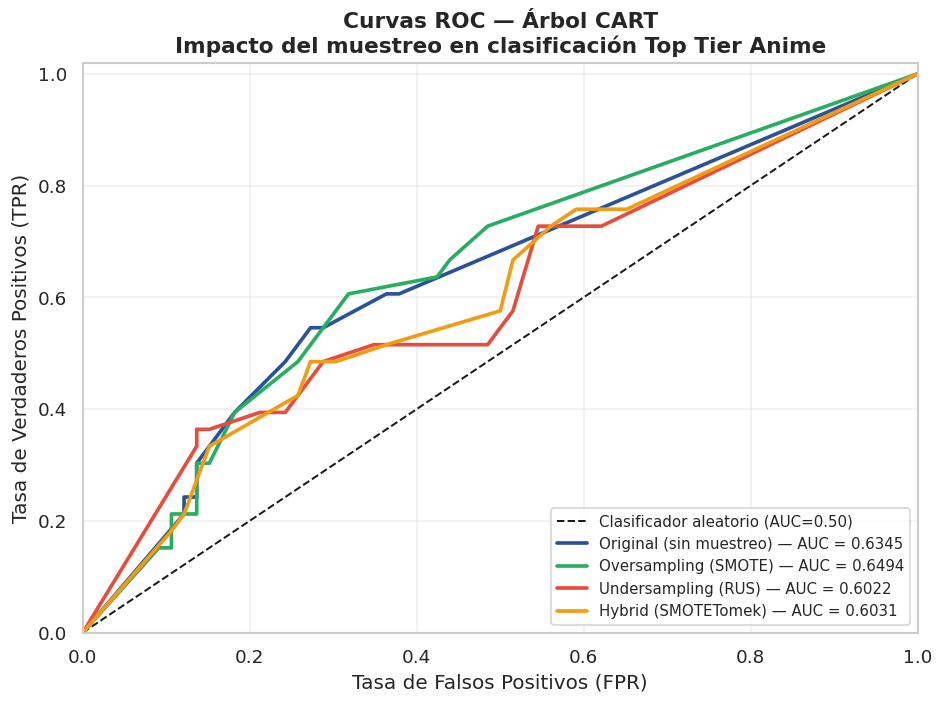

💾 Guardado: data/graficas/cart_roc_muestreo.png


In [8]:
# ── CELDA 8: Curvas ROC — los 4 métodos superpuestos ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r in resultados:
    ax.plot(r['fpr'], r['tpr'], color=r['color'], lw=2.2,
            label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol CART\nImpacto del muestreo en clasificación Top Tier Anime',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/graficas/cart_roc_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_roc_muestreo.png")

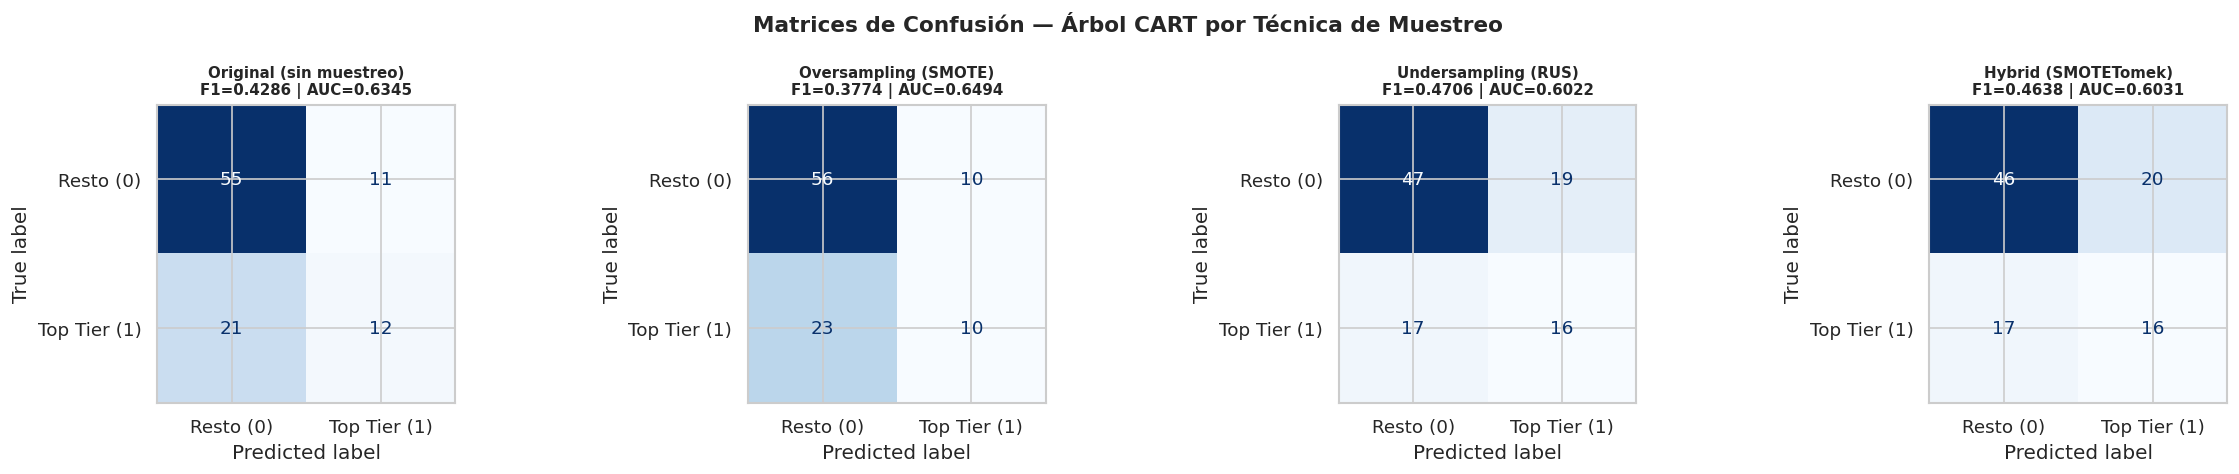

💾 Guardado: data/graficas/cart_confusion_muestreo.png


In [9]:
# ── CELDA 9: Matrices de Confusión — los 4 métodos ───────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrices de Confusión — Árbol CART por Técnica de Muestreo',
             fontsize=13, fontweight='bold')

for ax, r in zip(axes, resultados):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Resto (0)', 'Top Tier (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nF1={r['f1']:.4f} | AUC={r['roc_auc']:.4f}",
                 fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/cart_confusion_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_confusion_muestreo.png")

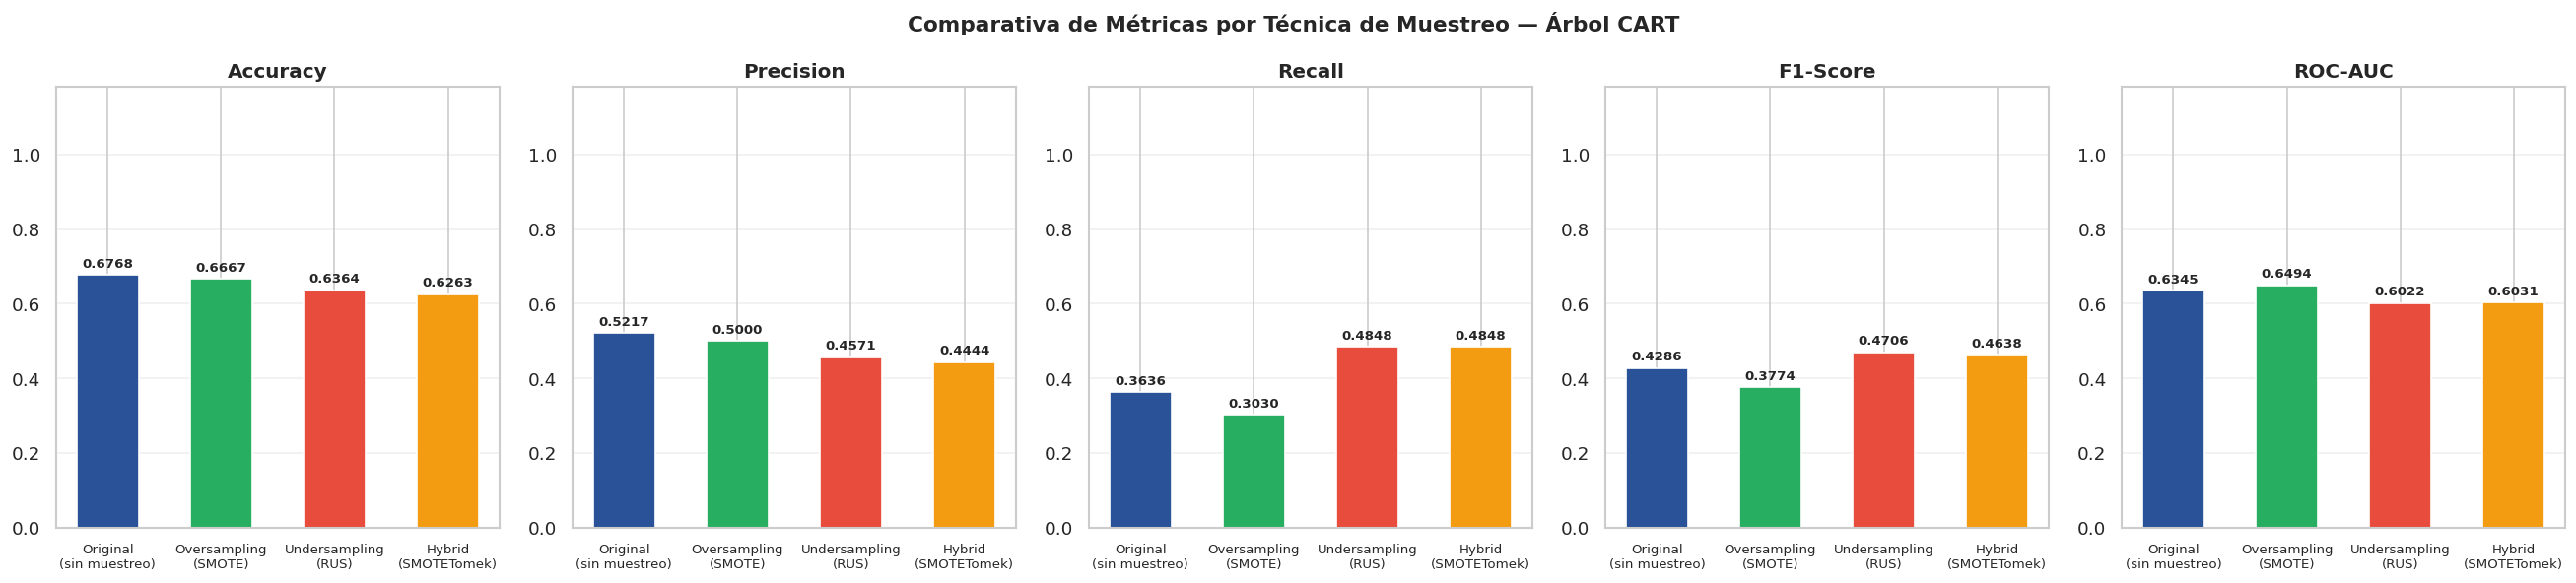

💾 Guardado: data/graficas/cart_comparativa_muestreo.png


In [10]:
# ── CELDA 10: Gráfica comparativa de métricas ────────────────────────────────
metricas_keys   = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, len(metricas_keys), figsize=(22, 5))
fig.suptitle('Comparativa de Métricas por Técnica de Muestreo — Árbol CART',
             fontsize=13, fontweight='bold')

nombres = [r['nombre'].replace(' (', '\n(') for r in resultados]
colores = [r['color'] for r in resultados]

for ax, key, label in zip(axes, metricas_keys, metricas_labels):
    vals = [r[key] for r in resultados]
    ax.bar(nombres, vals, color=colores, edgecolor='white', width=0.55)
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.18)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('data/graficas/cart_comparativa_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_comparativa_muestreo.png")

Modelo de referencia: Undersampling (RUS)

Suma de importancias: 1.000000  (debe ser ≈ 1.0)


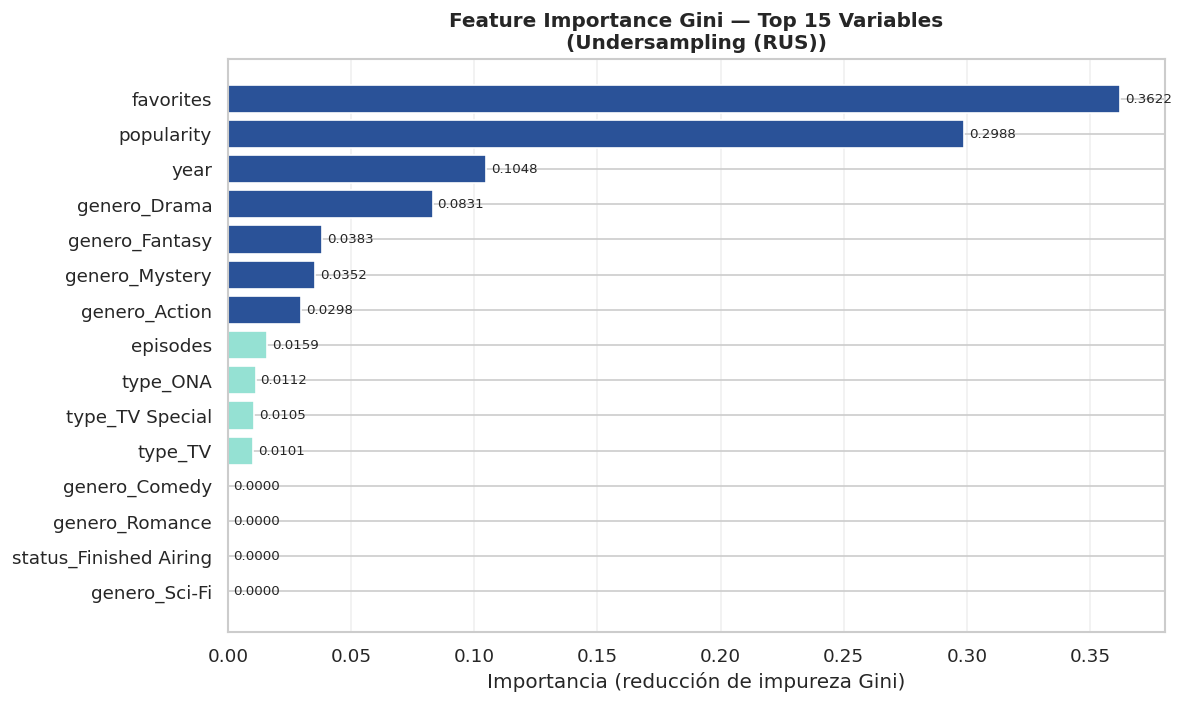

💾 Guardado: data/graficas/cart_importancia_muestreo.png


In [11]:
# ── CELDA 11: Feature Importance Gini ────────────────────────────────────────
# Usamos el modelo con mejor F1-Score
mejor = max(resultados, key=lambda r: r['f1'])
print(f"Modelo de referencia: {mejor['nombre']}")

importancias = pd.Series(
    mejor['modelo'].feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# Solo mostrar top 15 para legibilidad
top15 = importancias.tail(15)

fig, ax = plt.subplots(figsize=(10, 6))
colores_imp = ['#2a5298' if v > top15.median() else '#95e1d3' for v in top15.values]
bars = ax.barh(top15.index, top15.values, color=colores_imp, edgecolor='white')
ax.set_title(f'Feature Importance Gini — Top 15 Variables\n({mejor["nombre"]})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini)')
for bar, v in zip(bars, top15.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
print(f"\nSuma de importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
plt.tight_layout()
plt.savefig('data/graficas/cart_importancia_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_importancia_muestreo.png")

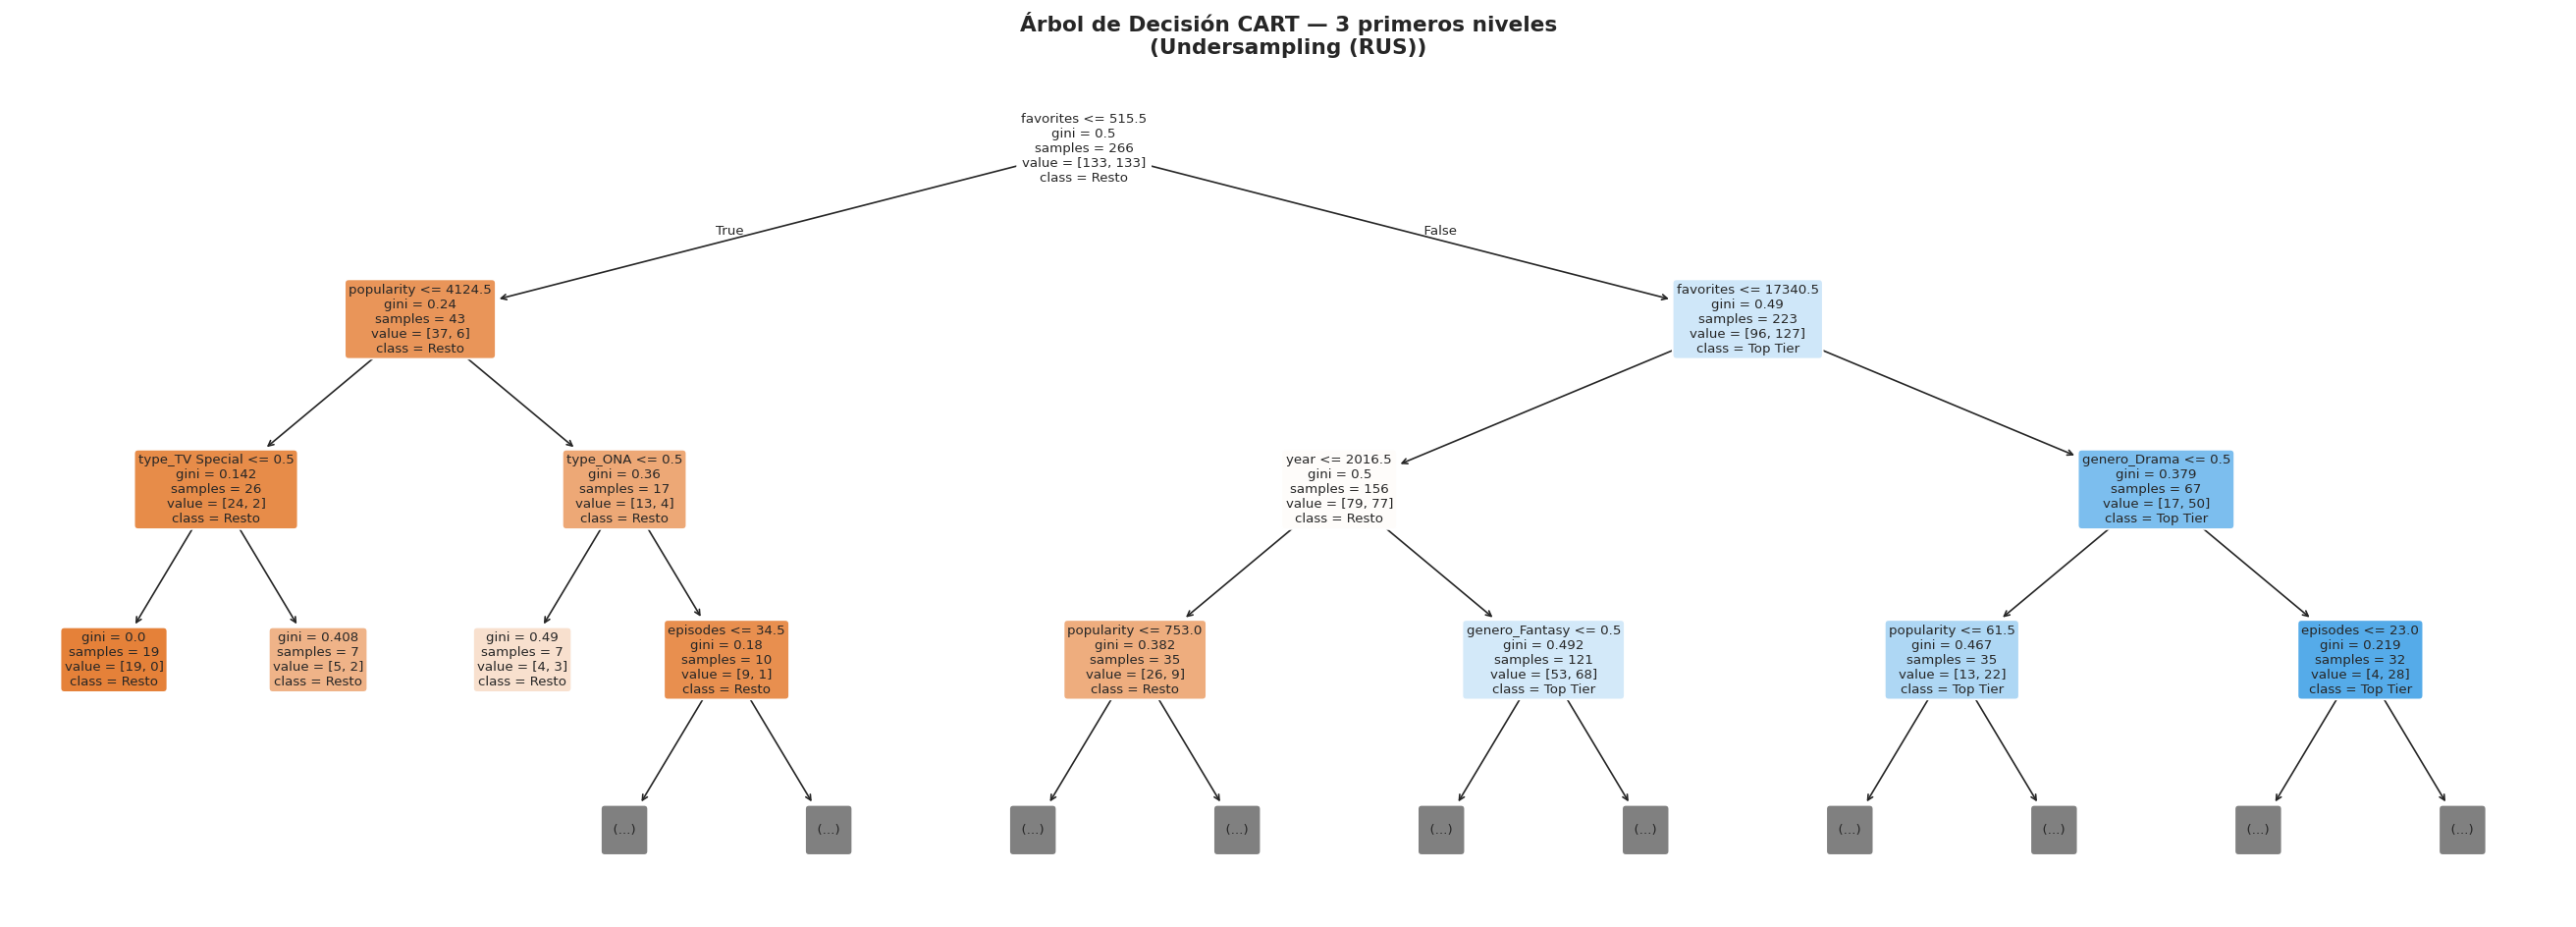

💾 Guardado: data/graficas/cart_arbol_muestreo.png


In [12]:
# ── CELDA 12: Visualización del árbol (3 niveles) ────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    mejor['modelo'], max_depth=3,
    feature_names=FEATURES,
    class_names=['Resto', 'Top Tier'],
    filled=True, rounded=True,
    fontsize=8, ax=ax
)
ax.set_title(f'Árbol de Decisión CART — 3 primeros niveles\n({mejor["nombre"]})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/graficas/cart_arbol_muestreo.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Guardado: data/graficas/cart_arbol_muestreo.png")

In [13]:
# ── CELDA 13: Tabla final con gradiente de color ─────────────────────────────
resumen = pd.DataFrame([{
    'Técnica'        : r['nombre'],
    'N Train'        : r['train_size'],
    'N Test'         : r['test_size'],
    'Dist. Train'    : r['dist_train'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados]).set_index('Técnica')

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS — ÁRBOL CART':^65}")
print("=" * 65)
display(
    resumen.style
    .background_gradient(cmap='Greens',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}',
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol CART — Clasificación Top Tier Anime · Impacto del muestreo")
)

# Análisis automático
mejor_f1  = resumen['F1-Score'].idxmax()
mejor_auc = resumen['ROC-AUC'].idxmax()

print(f"\n1. MEJOR MODELO (por F1-Score): {mejor_f1}")
print(f"   F1={resumen.loc[mejor_f1,'F1-Score']:.4f}  AUC={resumen.loc[mejor_f1,'ROC-AUC']:.4f}")
print(f"\n2. MEJOR MODELO (por AUC):      {mejor_auc}")
print(f"   AUC={resumen.loc[mejor_auc,'ROC-AUC']:.4f}  F1={resumen.loc[mejor_auc,'F1-Score']:.4f}")

print("""
3. IMPACTO DEL MUESTREO
   · Original       → muestra el rendimiento base sin ajuste de clases
   · SMOTE          → genera muestras sintéticas de Top Tier en el espacio de features
   · RandomUnderSampler → reduce la clase mayoritaria (Resto) para equilibrar
   · SMOTETomek (Hybrid) → combina SMOTE + limpieza de frontera (Tomek Links)

4. ¿POR QUÉ SE ELIMINÓ 'rank'?
   rank está ordenado directamente por score (rank=1 → mejor score).
   Usarlo como feature sería data leakage: el modelo estaría aprendiendo
   de información directamente derivada de la variable objetivo.

5. NUEVAS VARIABLES INCLUIDAS
   · type    → One-Hot Encoding (TV, Movie, OVA, Special...)
   · status  → One-Hot Encoding (Finished, Airing...)
   · year    → Año de estreno — tendencias temporales en los scores
   · géneros → Variables binarias por género (Action, Drama, Comedy...)
""")

              TABLA FINAL DE MÉTRICAS — ÁRBOL CART               


,N Train,N Test,Dist. Train,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Técnica,,,,,,,,
Original (sin muestreo),393,99,0:260 / 1:133,0.6768,0.5217,0.3636,0.4286,0.6345
Oversampling (SMOTE),520,99,0:260 / 1:260,0.6667,0.5000,0.3030,0.3774,0.6494
Undersampling (RUS),266,99,0:133 / 1:133,0.6364,0.4571,0.4848,0.4706,0.6022
Hybrid (SMOTETomek),446,99,0:223 / 1:223,0.6263,0.4444,0.4848,0.4638,0.6031



1. MEJOR MODELO (por F1-Score): Undersampling (RUS)
   F1=0.4706  AUC=0.6022

2. MEJOR MODELO (por AUC):      Oversampling (SMOTE)
   AUC=0.6494  F1=0.3774

3. IMPACTO DEL MUESTREO
   · Original       → muestra el rendimiento base sin ajuste de clases
   · SMOTE          → genera muestras sintéticas de Top Tier en el espacio de features
   · RandomUnderSampler → reduce la clase mayoritaria (Resto) para equilibrar
   · SMOTETomek (Hybrid) → combina SMOTE + limpieza de frontera (Tomek Links)

4. ¿POR QUÉ SE ELIMINÓ 'rank'?
   rank está ordenado directamente por score (rank=1 → mejor score).
   Usarlo como feature sería data leakage: el modelo estaría aprendiendo
   de información directamente derivada de la variable objetivo.

5. NUEVAS VARIABLES INCLUIDAS
   · type    → One-Hot Encoding (TV, Movie, OVA, Special...)
   · status  → One-Hot Encoding (Finished, Airing...)
   · year    → Año de estreno — tendencias temporales en los scores
   · géneros → Variables binarias por género (Actio